# Cyber Mini-Defense Toolkit

## Final Project — AI & Cybersecurity

### Project Overview

This project develops a Cyber Mini-Defense Toolkit that uses Python to analyze cybersecurity login activity and demonstrate practical cybersecurity defense techniques. The project examines login behavior to identify failed login attempts, unusual activity, and patterns that may indicate suspicious behavior.

In addition to analyzing cybersecurity login data, the toolkit demonstrates multiple cybersecurity concepts and tools, including rule-based threat detection, password security, phishing detection, and other defensive techniques. The project also considers how automation and artificial intelligence can support cybersecurity professionals while recognizing the importance of human oversight when evaluating security alerts.

### Project Objectives

The objectives of this project are to:

- Analyze cybersecurity login data using Python.
- Identify failed login attempts and suspicious login behavior.
- Examine patterns associated with unusual login activity.
- Develop a rule-based method for detecting potentially suspicious activity.
- Demonstrate practical cybersecurity defense tools.
- Explore how AI and automation can support cybersecurity analysis.
- Communicate cybersecurity findings and security recommendations.

## 1. Environment Setup

The first step establishes the Python environment and imports the libraries needed for data analysis and visualization. Pandas supports the analysis and manipulation of the cybersecurity dataset, NumPy provides numerical capabilities, and Matplotlib supports data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Dataset Loading and Understanding

The project uses the Cybersecurity Login Dataset to examine login behavior and identify potentially suspicious activity. The dataset is loaded into a Pandas DataFrame so that its structure, variables, and security indicators can be explored before conducting the detailed analysis.

In [2]:
logs = pd.read_csv("/content/cybersecurity_login_dataset (1) - cybersecurity_login_dataset (1).csv")
logs.head()

,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
0,4,0,1,0,0
1,5,5,0,0,0
2,14,0,0,0,0
3,8,8,0,0,0
4,21,17,1,0,1


### Initial Data Exploration

Before analyzing suspicious activity, I reviewed the size, structure, data types, and classifications contained in the dataset. This step helps confirm that the data loaded correctly and identifies any data-quality issues that could affect the analysis.

In [3]:
logs.shape

(600, 5)

In [4]:
logs.columns

Index(['login_attempts', 'failed_logins', 'unusual_login_hour',
       'new_ip_address', 'suspicious'],
      dtype='object')

In [5]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   login_attempts      600 non-null    int64
 1   failed_logins       600 non-null    int64
 2   unusual_login_hour  600 non-null    int64
 3   new_ip_address      600 non-null    int64
 4   suspicious          600 non-null    int64
dtypes: int64(5)
memory usage: 23.6 KB


In [6]:
logs["suspicious"].value_counts()

,count
suspicious,
1,367
0,233


### Dataset Overview

The Cybersecurity Login Dataset contains 600 login activity records and five variables: login attempts, failed logins, unusual login hours, new IP address activity, and suspicious activity classification. The dataset contains no missing values, which allowed me to proceed with the analysis without additional treatment for incomplete records.

Of the 600 records, 367 were classified as suspicious and 233 were classified as non-suspicious. This initial review provided the baseline for examining which login behaviors were most strongly associated with suspicious activity.

## 3. Failed Login Analysis

Failed login attempts can provide an important indicator of potential unauthorized access. This section examines the frequency and distribution of failed logins to identify patterns that may warrant additional security review.

In [7]:
# Analyze failed login activity

total_failed_logins = logs["failed_logins"].sum()

print("Total Failed Login Attempts:", total_failed_logins)

Total Failed Login Attempts: 3845


In [8]:
# Analyze the distribution of failed login attempts

failed_login_counts = logs["failed_logins"].value_counts().sort_index()

print("Failed Login Distribution:")
print(failed_login_counts)

Failed Login Distribution:
failed_logins
0     63
1     64
2     58
3     59
4     45
5     43
6     36
7     32
8     22
9     28
10    21
11    18
12     8
13    13
14    13
15    21
16     5
17    16
18     9
19     7
20     4
21     8
22     3
23     3
25     1
Name: count, dtype: int64


In [9]:
# Identify the maximum number of failed logins in a single record

max_failed_logins = logs["failed_logins"].max()

print("Maximum Failed Logins in a Single Record:", max_failed_logins)

Maximum Failed Logins in a Single Record: 25


### Failed Login Analysis Findings

The dataset contains 3,845 failed login attempts across 600 login records. The number of failed logins in an individual record ranges from zero to 25, with 25 representing the highest number observed.

Repeated failed login attempts can indicate password guessing, credential abuse, or other attempts to gain unauthorized access. However, failed logins alone do not confirm malicious activity because legitimate users may also enter incorrect credentials. For this reason, I considered failed login activity together with additional indicators such as unusual login hours, new IP address activity, and overall login volume.

## 4. Suspicious Activity Analysis

This section examines records classified as suspicious and compares them with non-suspicious activity. The analysis considers login attempts, failed logins, unusual login hours, and new IP address activity to determine which characteristics appear more frequently in suspicious records.

In [10]:
# Identify suspicious login records

suspicious_records = logs[logs["suspicious"] == 1]

print("Total Suspicious Records:", len(suspicious_records))
suspicious_records.head(10)

Total Suspicious Records: 367


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
4,21,17,1,0,1
5,19,8,0,0,1
7,25,10,0,0,1
8,4,2,1,1,1
9,24,14,0,1,1
10,18,9,1,0,1
12,8,1,1,1,1
13,21,11,0,1,1
15,24,7,0,1,1
17,25,1,0,0,1


In [11]:
# Compare average login behavior for suspicious and non-suspicious activity

comparison = logs.groupby("suspicious")[
    ["login_attempts", "failed_logins", "unusual_login_hour", "new_ip_address"]
].mean()

comparison

,login_attempts,failed_logins,unusual_login_hour,new_ip_address
suspicious,,,,
0,7.733906,3.017167,0.304721,0.377682
1,16.653951,8.561308,0.643052,0.651226


In [12]:
# Identify records with a high number of failed login attempts

high_failed_logins = logs[logs["failed_logins"] >= 10]

print("Records with 10 or More Failed Logins:", len(high_failed_logins))

high_failed_logins.sort_values(
    by="failed_logins",
    ascending=False
).head(10)

Records with 10 or More Failed Logins: 150


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
434,25,25,0,1,1
28,24,23,1,0,1
117,24,23,0,1,1
429,25,23,1,1,1
377,23,22,0,1,1
59,22,22,1,0,1
483,22,22,0,0,1
161,21,21,0,0,1
313,24,21,0,1,1
208,21,21,1,0,1


In [13]:
# Identify activity involving both a new IP address and an unusual login hour

new_ip_unusual_hour = logs[
    (logs["new_ip_address"] == 1) &
    (logs["unusual_login_hour"] == 1)
]

print(
    "Records with New IP Address and Unusual Login Hour:",
    len(new_ip_unusual_hour)
)

new_ip_unusual_hour.head(10)

Records with New IP Address and Unusual Login Hour: 169


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
8,4,2,1,1,1
12,8,1,1,1,1
21,8,8,1,1,1
25,13,9,1,1,1
26,1,0,1,1,1
31,1,0,1,1,1
34,16,5,1,1,1
35,18,6,1,1,1
36,21,11,1,1,1
43,22,13,1,1,1


### Suspicious Activity Findings

The comparison between suspicious and non-suspicious records identified several clear differences. Suspicious records averaged approximately 16.65 login attempts compared with 7.73 for non-suspicious records. Suspicious activity also averaged approximately 8.56 failed logins, while non-suspicious activity averaged approximately 3.02 failed logins.

Unusual login hours and new IP address activity also appeared more frequently among suspicious records. Approximately 64.3% of suspicious records involved an unusual login hour, compared with approximately 30.5% of non-suspicious records. Similarly, approximately 65.1% of suspicious records involved a new IP address, compared with approximately 37.8% of non-suspicious records.

The analysis also identified 150 records with 10 or more failed login attempts and 169 records involving both a new IP address and an unusual login hour. These findings demonstrate that combining multiple security indicators provides greater context than relying on one event alone.

## 5. Rule-Based Suspicious Login Detection

The next component of the Cyber Mini-Defense Toolkit uses a rule-based approach to identify potentially suspicious login activity. Rather than relying on a single indicator, the detector assigns risk based on several characteristics, including repeated failed login attempts, unusual login hours, new IP address activity, and high overall login volume.

This approach demonstrates how cybersecurity analysts can combine multiple indicators to support automated threat detection. The rule-based detector does not replace human analysis, but it can help prioritize activity that may require additional investigation.

In [14]:
# Build a rule-based suspicious login detector

def detect_suspicious_login(row):
    risk_score = 0

    # High number of failed login attempts
    if row["failed_logins"] >= 10:
        risk_score += 2

    # Login occurred during an unusual hour
    if row["unusual_login_hour"] == 1:
        risk_score += 1

    # Login came from a new IP address
    if row["new_ip_address"] == 1:
        risk_score += 1

    # High overall login activity
    if row["login_attempts"] >= 15:
        risk_score += 1

    # Flag activity when multiple risk indicators are present
    if risk_score >= 2:
        return 1
    else:
        return 0

In [15]:
# Apply the rule-based detector to the dataset

logs["rule_based_prediction"] = logs.apply(
    detect_suspicious_login,
    axis=1
)

logs[
    [
        "login_attempts",
        "failed_logins",
        "unusual_login_hour",
        "new_ip_address",
        "suspicious",
        "rule_based_prediction"
    ]
].head(15)

,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious,rule_based_prediction
0,4,0,1,0,0,0
1,5,5,0,0,0,0
2,14,0,0,0,0,0
3,8,8,0,0,0,0
4,21,17,1,0,1,1
5,19,8,0,0,1,0
6,14,5,1,0,0,0
7,25,10,0,0,1,1
8,4,2,1,1,1,1
9,24,14,0,1,1,1


In [16]:
# Count the predictions made by the rule-based detector

logs["rule_based_prediction"].value_counts()

,count
rule_based_prediction,
1,338
0,262


In [17]:
# Evaluate the rule-based detector

correct_predictions = (
    logs["rule_based_prediction"] == logs["suspicious"]
).sum()

total_records = len(logs)

accuracy = correct_predictions / total_records

print("Correct Predictions:", correct_predictions)
print("Total Records:", total_records)
print("Rule-Based Detector Accuracy:", round(accuracy * 100, 2), "%")

Correct Predictions: 555
Total Records: 600
Rule-Based Detector Accuracy: 92.5 %


### Rule-Based Detection Findings

The rule-based detector classified 338 of the 600 login records as potentially suspicious and classified 262 records as non-suspicious. When I compared these predictions with the suspicious activity classifications contained in the original dataset, the detector correctly classified 555 of the 600 records, producing an overall accuracy of 92.5%.

The results demonstrate that relatively simple cybersecurity rules can identify a substantial amount of suspicious activity when they combine multiple indicators. In this analysis, failed login attempts received greater weight because repeated authentication failures may represent an elevated security concern. Unusual login hours, new IP addresses, and high login volume provided additional indicators of potentially abnormal behavior.

Although the detector achieved strong performance on this dataset, a rule-based system has limitations. Thresholds may produce false positives or fail to identify attacks that do not match predefined rules. A cybersecurity analyst should therefore treat automated detection as a decision-support capability and investigate relevant alerts before determining whether an actual security incident occurred.

## 6. Cybersecurity Defense Tools

In addition to analyzing login activity, the Cyber Mini-Defense Toolkit includes practical tools that address other common cybersecurity risks. The following tools demonstrate how Python can support password security and phishing detection.

These tools use straightforward security rules to evaluate potential risks and provide users with understandable feedback. They demonstrate how basic automation can support cybersecurity awareness and defensive security practices.

### 6.1 Password Strength Checker

Weak passwords can increase the risk of unauthorized access, particularly when passwords are short or lack character diversity. This tool evaluates password strength by examining password length and the use of uppercase letters, lowercase letters, numbers, and special characters.

In [18]:
# Password Strength Checker

import re

def check_password_strength(password):
    score = 0
    recommendations = []

    # Check password length
    if len(password) >= 12:
        score += 1
    else:
        recommendations.append("Use at least 12 characters.")

    # Check for uppercase letters
    if re.search(r"[A-Z]", password):
        score += 1
    else:
        recommendations.append("Add an uppercase letter.")

    # Check for lowercase letters
    if re.search(r"[a-z]", password):
        score += 1
    else:
        recommendations.append("Add a lowercase letter.")

    # Check for numbers
    if re.search(r"[0-9]", password):
        score += 1
    else:
        recommendations.append("Add a number.")

    # Check for special characters
    if re.search(r"[^A-Za-z0-9]", password):
        score += 1
    else:
        recommendations.append("Add a special character.")

    # Determine password strength
    if score == 5:
        strength = "Strong"
    elif score >= 3:
        strength = "Moderate"
    else:
        strength = "Weak"

    return strength, recommendations

In [19]:
# Test the password strength checker

test_passwords = [
    "password",
    "CyberSecurity1",
    "CyberDefense2026!",
    "AI&CyberSecurity#2026"
]

for password in test_passwords:
    strength, recommendations = check_password_strength(password)

    print("Password:", password)
    print("Strength:", strength)

    if recommendations:
        print("Recommendations:")
        for recommendation in recommendations:
            print("-", recommendation)

    print("-" * 40)

Password: password
Strength: Weak
Recommendations:
- Use at least 12 characters.
- Add an uppercase letter.
- Add a number.
- Add a special character.
----------------------------------------
Password: CyberSecurity1
Strength: Moderate
Recommendations:
- Add a special character.
----------------------------------------
Password: CyberDefense2026!
Strength: Strong
----------------------------------------
Password: AI&CyberSecurity#2026
Strength: Strong
----------------------------------------


#### Password Strength Checker Findings

The password strength checker successfully distinguished between weak, moderate, and strong demonstration passwords. The basic password "password" received a weak rating because it did not meet the length requirement and lacked uppercase letters, numbers, and special characters. "CyberSecurity1" received a moderate rating because it contained uppercase and lowercase letters and a number but did not contain a special character.

The two longer demonstration passwords met all five criteria and received strong ratings. These results demonstrate how automated password checks can provide immediate feedback and encourage stronger password practices. However, meeting basic complexity requirements does not guarantee that a password is secure. Organizations should combine strong password practices with additional protections such as multifactor authentication and secure credential management.

### 6.2 Phishing Detector

Phishing attacks often attempt to persuade users to reveal credentials, provide sensitive information, open malicious attachments, or visit fraudulent websites. This tool uses a simple rule-based approach to examine message content for common warning signs such as urgent language, requests for passwords, suspicious links, financial claims, and threats involving account access.

The purpose of the tool is not to determine with certainty whether a message is malicious. Instead, it demonstrates how automated analysis can identify warning signs and help users determine when a message requires additional review.

In [20]:
# Rule-Based Phishing Detector

def detect_phishing(message):
    message_lower = message.lower()

    suspicious_terms = [
        "urgent",
        "verify your account",
        "password",
        "click here",
        "immediately",
        "account suspended",
        "confirm your identity",
        "bank account",
        "winner",
        "prize",
        "limited time"
    ]

    detected_terms = []

    for term in suspicious_terms:
        if term in message_lower:
            detected_terms.append(term)

    risk_score = len(detected_terms)

    if risk_score >= 3:
        risk_level = "High Risk"
    elif risk_score >= 1:
        risk_level = "Potential Risk"
    else:
        risk_level = "Low Risk"

    return risk_level, detected_terms

In [21]:
# Test the phishing detector with demonstration messages

test_messages = [
    "The department meeting has been moved to 2:00 PM tomorrow.",

    "Urgent: Verify your account immediately to prevent interruption.",

    "Congratulations! You are a winner. Click here immediately to claim your prize.",

    "Your account has been suspended. Click here to confirm your identity and password immediately."
]

for message in test_messages:
    risk_level, detected_terms = detect_phishing(message)

    print("Message:", message)
    print("Risk Level:", risk_level)

    if detected_terms:
        print("Detected Warning Signs:")
        for term in detected_terms:
            print("-", term)
    else:
        print("Detected Warning Signs: None")

    print("-" * 60)

Message: The department meeting has been moved to 2:00 PM tomorrow.
Risk Level: Low Risk
Detected Warning Signs: None
------------------------------------------------------------
Message: Urgent: Verify your account immediately to prevent interruption.
Risk Level: High Risk
Detected Warning Signs:
- urgent
- verify your account
- immediately
------------------------------------------------------------
Message: Congratulations! You are a winner. Click here immediately to claim your prize.
Risk Level: High Risk
Detected Warning Signs:
- click here
- immediately
- winner
- prize
------------------------------------------------------------
Message: Your account has been suspended. Click here to confirm your identity and password immediately.
Risk Level: High Risk
Detected Warning Signs:
- password
- click here
- immediately
- confirm your identity
------------------------------------------------------------


#### Phishing Detector Findings

The phishing detector demonstrated how rule-based analysis can identify common warning signs within potentially malicious messages. A routine meeting message produced a low-risk classification because it contained none of the predefined warning signs. Messages containing urgent language, requests to verify account information, suspicious instructions, or claims involving prizes produced higher risk classifications as additional indicators appeared.

The results demonstrate the value of examining multiple characteristics rather than relying on a single word or phrase. At the same time, a rule-based phishing detector has limitations. Legitimate messages may contain words such as "urgent," while sophisticated phishing messages may avoid obvious warning signs entirely. For this reason, automated phishing detection should support, rather than replace, user awareness and human review.

## 7. Cybersecurity Data Visualization

Data visualization provides another way to examine cybersecurity activity and communicate security findings. The following visualizations summarize suspicious login classifications, failed login activity, and differences between suspicious and non-suspicious records.

Visualizing these patterns can help cybersecurity analysts identify trends, communicate findings, and determine which activities may require additional investigation.

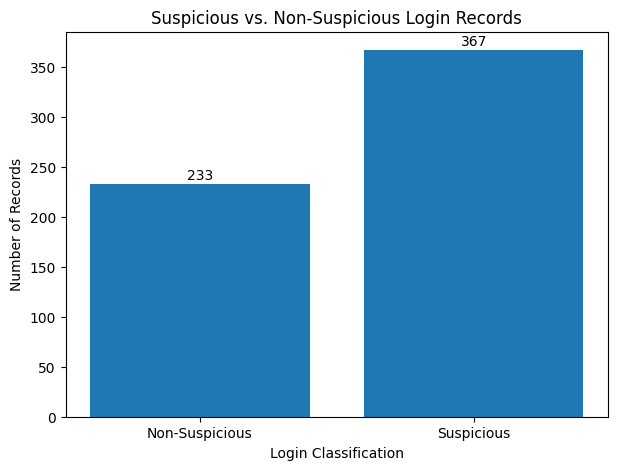

In [22]:
# Visualize suspicious and non-suspicious login records

suspicious_counts = logs["suspicious"].value_counts().sort_index()

labels = ["Non-Suspicious", "Suspicious"]

plt.figure(figsize=(7, 5))
plt.bar(labels, suspicious_counts.values)

plt.title("Suspicious vs. Non-Suspicious Login Records")
plt.xlabel("Login Classification")
plt.ylabel("Number of Records")

for i, value in enumerate(suspicious_counts.values):
    plt.text(i, value + 5, str(value), ha="center")

plt.show()

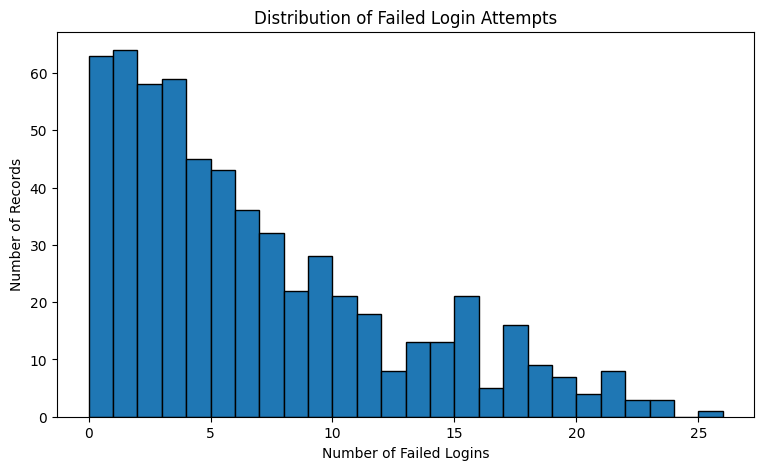

In [23]:
# Visualize the distribution of failed login attempts

plt.figure(figsize=(9, 5))

plt.hist(
    logs["failed_logins"],
    bins=range(0, logs["failed_logins"].max() + 2),
    edgecolor="black"
)

plt.title("Distribution of Failed Login Attempts")
plt.xlabel("Number of Failed Logins")
plt.ylabel("Number of Records")

plt.show()

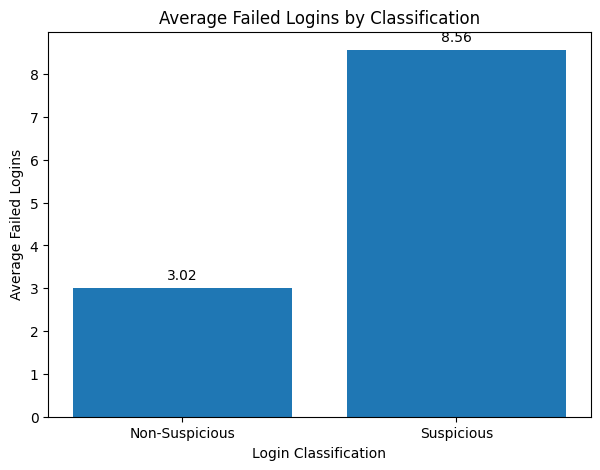

In [24]:
# Compare average failed logins by classification

average_failed = logs.groupby("suspicious")["failed_logins"].mean()

labels = ["Non-Suspicious", "Suspicious"]

plt.figure(figsize=(7, 5))
plt.bar(labels, average_failed.values)

plt.title("Average Failed Logins by Classification")
plt.xlabel("Login Classification")
plt.ylabel("Average Failed Logins")

for i, value in enumerate(average_failed.values):
    plt.text(i, value + 0.2, f"{value:.2f}", ha="center")

plt.show()

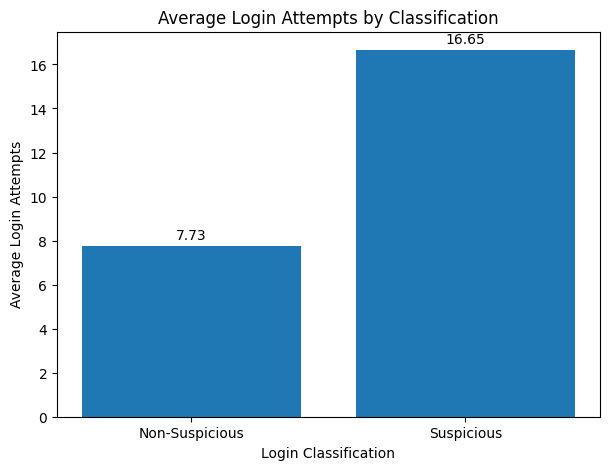

In [25]:
# Compare average login attempts by classification

average_attempts = logs.groupby("suspicious")["login_attempts"].mean()

labels = ["Non-Suspicious", "Suspicious"]

plt.figure(figsize=(7, 5))
plt.bar(labels, average_attempts.values)

plt.title("Average Login Attempts by Classification")
plt.xlabel("Login Classification")
plt.ylabel("Average Login Attempts")

for i, value in enumerate(average_attempts.values):
    plt.text(i, value + 0.3, f"{value:.2f}", ha="center")

plt.show()

### Visualization Findings

The visualizations reinforce the patterns identified during the login analysis. Of the 600 records in the dataset, 367 were classified as suspicious and 233 as non-suspicious, indicating that suspicious activity represents a substantial portion of the dataset.

The failed login distribution also shows that authentication failures occurred at varying levels across the records. More importantly, suspicious records averaged approximately 8.56 failed login attempts compared with 3.02 for non-suspicious records. Suspicious records also averaged approximately 16.65 total login attempts compared with 7.73 for non-suspicious records.

These differences demonstrate that higher login activity and repeated authentication failures are important indicators within this dataset. However, these indicators should be considered together with contextual factors such as unusual login hours and new IP addresses rather than treated as independent proof of malicious activity.

## 8. Security Recommendations

Based on the findings from the Cyber Mini-Defense Toolkit, organizations should use multiple security controls to reduce authentication and account-related risks.

**1. Monitor repeated failed login attempts.**  
Organizations should establish monitoring and alerting procedures for accounts that experience repeated authentication failures. A high number of failed attempts may indicate password guessing, credential attacks, or attempted unauthorized access.

**2. Evaluate multiple risk indicators.**  
Security teams should consider failed logins together with other indicators such as unusual login times, new IP addresses, and abnormal login volume. Combining multiple indicators provides greater context and can improve alert prioritization.

**3. Strengthen authentication practices.**  
Organizations should encourage strong passwords and implement multifactor authentication where appropriate. Password strength requirements should form one part of a broader identity and access management strategy.

**4. Maintain phishing awareness.**  
Users should receive training to recognize common phishing indicators, including urgent requests, suspicious links, credential requests, and unexpected account warnings. Automated detection can support this process, but users should continue to evaluate suspicious communications carefully.

**5. Maintain human oversight.**  
Automated cybersecurity tools can process large amounts of information and identify patterns quickly, but analysts should review significant security alerts before taking consequential actions. Human oversight helps provide context, investigate false positives, and determine the appropriate response.

## 9. Responsible Use of AI and Automation

Artificial intelligence and automation can improve cybersecurity operations by helping analysts process large amounts of security data, identify unusual patterns, prioritize alerts, and respond more quickly to potential threats. The tools developed in this project demonstrate this concept at a smaller scale by automatically evaluating login behavior, password characteristics, and potential phishing indicators.

Automation also introduces limitations. A rule-based system depends on the criteria and thresholds established by its developer, while more advanced AI systems depend on the quality of their data and models. Both approaches can produce false positives or fail to identify previously unseen threats.

For these reasons, organizations should use AI and automated cybersecurity tools as decision-support capabilities rather than relying on them without oversight. Security professionals should validate important findings, monitor system performance, protect sensitive data, document significant decisions, and periodically review detection methods as threats and organizational environments change.

## 10. Project Conclusion

The Cyber Mini-Defense Toolkit demonstrates how Python, data analysis, and basic automation can support practical cybersecurity activities. I analyzed 600 login records and identified patterns associated with suspicious behavior, including increased login activity, repeated failed authentication attempts, unusual login hours, and new IP address activity.

I also developed a rule-based suspicious login detector that correctly classified 555 of the 600 records, resulting in an accuracy of 92.5%. The additional password strength checker and phishing detector demonstrated how Python can support other defensive cybersecurity activities by providing users with immediate security feedback.

The project also demonstrates an important cybersecurity principle: no single indicator should determine whether an activity represents a threat. Effective cybersecurity requires analysts to combine technical indicators with context, human judgment, and appropriate security controls. AI and automation can strengthen this process by improving the speed and consistency of analysis, but human oversight remains necessary when evaluating and responding to security events.

Overall, this project provided a practical demonstration of cybersecurity data analysis, threat detection, automation, visualization, and responsible security practices within a single Python-based toolkit.

## 11. Toolkit Components

The completed Cyber Mini-Defense Toolkit includes:

- Cybersecurity login data analysis
- Failed login analysis
- Suspicious activity analysis
- Rule-based suspicious login detector
- Password strength checker
- Phishing detector
- Cybersecurity data visualizations
- Security recommendations
- Responsible AI and automation considerations

Together, these components demonstrate how Python and automated analysis can support cybersecurity professionals in identifying, evaluating, and communicating potential security risks.